In [1]:
import zipfile
import io
import os
import numpy as np
import numpy.random as random
import scipy as sp
import pandas as pd
from pandas import Series, DataFrame

# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
%matplotlib inline

# Display up to three decimal places
%precision 3

'%.3f'

In [34]:
web_traffic = pd.read_csv("../data/web_traffic.csv")
customers = pd.read_csv("../data/customers.csv")
orders = pd.read_csv("../data/orders.csv")
order_item = pd.read_csv("../data/order_items.csv")
shipments = pd.read_csv("../data/shipments.csv")
reviews = pd.read_csv("../data/reviews.csv")
promotions = pd.read_csv("../data/promotions.csv")
sales = pd.read_csv("../data/sales.csv")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28260\4042407951.py:4: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_item = pd.read_csv("../data/order_items.csv")


In [32]:
# Get count as a DataFrame
orders_per_date = orders.groupby('order_date').size().reset_index(name='order_count')

# Sort by date
orders_per_date = orders_per_date.sort_values('order_date')

# Basic stats
print(f"Average orders per day: {orders_per_date['order_count'].mean():.2f}")
print(f"Max orders on a day: {orders_per_date['order_count'].max()}")
print(f"Min orders on a day: {orders_per_date['order_count'].min()}")

Average orders per day: 168.78
Max orders on a day: 803
Min orders on a day: 8


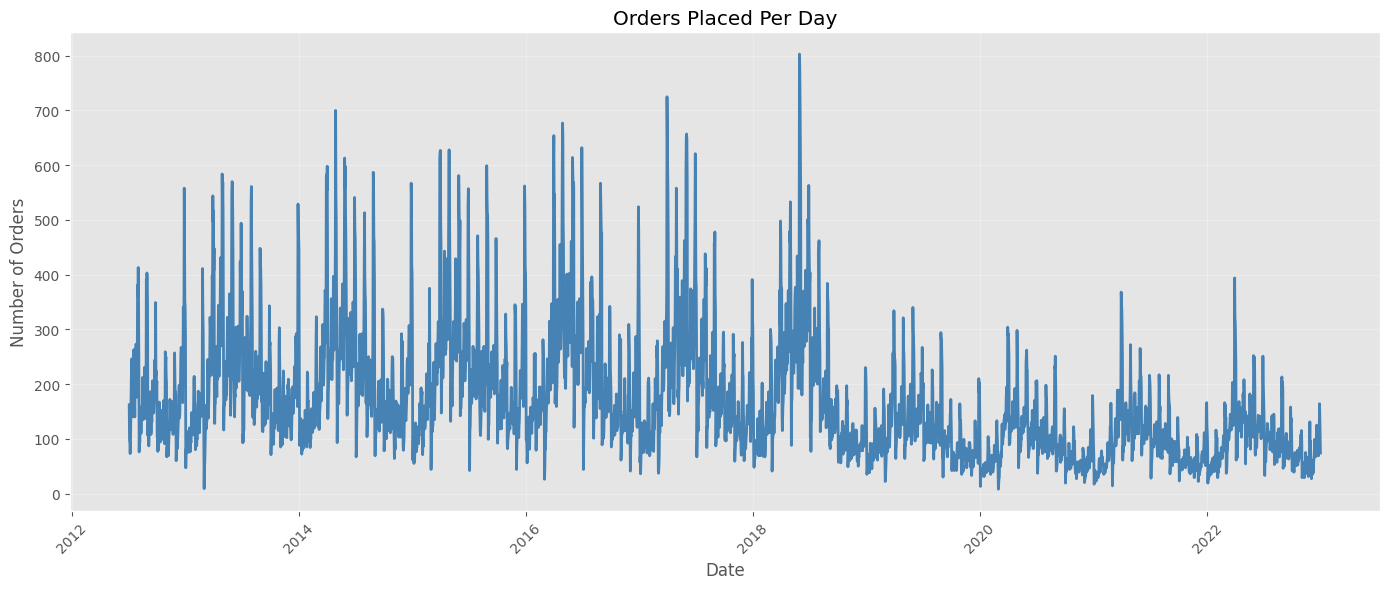

In [33]:
plt.figure(figsize=(14, 6))
plt.plot(orders_per_date['order_date'], orders_per_date['order_count'], linewidth=2, color='steelblue')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.title('Orders Placed Per Day')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
orders['date'] = pd.to_datetime(orders['order_date'])
post_2013_orders = orders[orders['date'] >= pd.to_datetime("2013-01-01")].copy()
post_2013_orders = post_2013_orders.groupby('date').size().reset_index(name='order_count')
post_2013_orders['order_date_by_web_traffic'] = (post_2013_orders['order_count']/web_traffic['unique_visitors']*100)
post_2013_orders.head(10)


,date,order_count,order_date_by_web_traffic
0,2013-01-01,288,3.970771
1,2013-01-02,47,0.576616
2,2013-01-03,81,1.086082
3,2013-01-04,83,1.029394
4,2013-01-05,78,0.989597
5,2013-01-06,93,1.330092
6,2013-01-07,113,1.536579
7,2013-01-08,90,1.206596
8,2013-01-09,75,1.055149
9,2013-01-10,79,1.002793


In [48]:
web_traffic.head(10)

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral
5,2013-01-06,9545,6992,47160,0.00438,263.6,social_media
6,2013-01-07,10203,7354,32749,0.00443,252.1,organic_search
7,2013-01-08,9456,7459,31482,0.00440,192.4,paid_search
8,2013-01-09,9162,7108,46717,0.00409,312.8,organic_search
9,2013-01-10,9887,7878,38472,0.00544,285.4,organic_search


In [8]:
web_traffic['traffic_source'].value_counts()

traffic_source
organic_search    1090
paid_search        784
social_media       632
email_campaign     505
referral           375
direct             266
Name: count, dtype: int64

In [21]:
promotions.isnull().sum()
promotions.fillna("ALL", axis = 1)

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,ALL,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,ALL,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,ALL,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,ALL,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000
5,PROMO-0006,Rural Special 2013,percentage,15.0,2013-01-31,2013-03-01,Outdoor,in_store,0,0
6,PROMO-0007,Spring Sale 2014,percentage,12.0,2014-03-18,2014-04-17,ALL,email,1,0
7,PROMO-0008,Mid-Year Sale 2014,percentage,18.0,2014-06-23,2014-07-22,ALL,social_media,0,0
8,PROMO-0009,Fall Launch 2014,percentage,10.0,2014-08-30,2014-10-01,ALL,all_channels,0,100000
9,PROMO-0010,Year-End Sale 2014,percentage,20.0,2014-11-19,2015-01-02,ALL,all_channels,0,100000


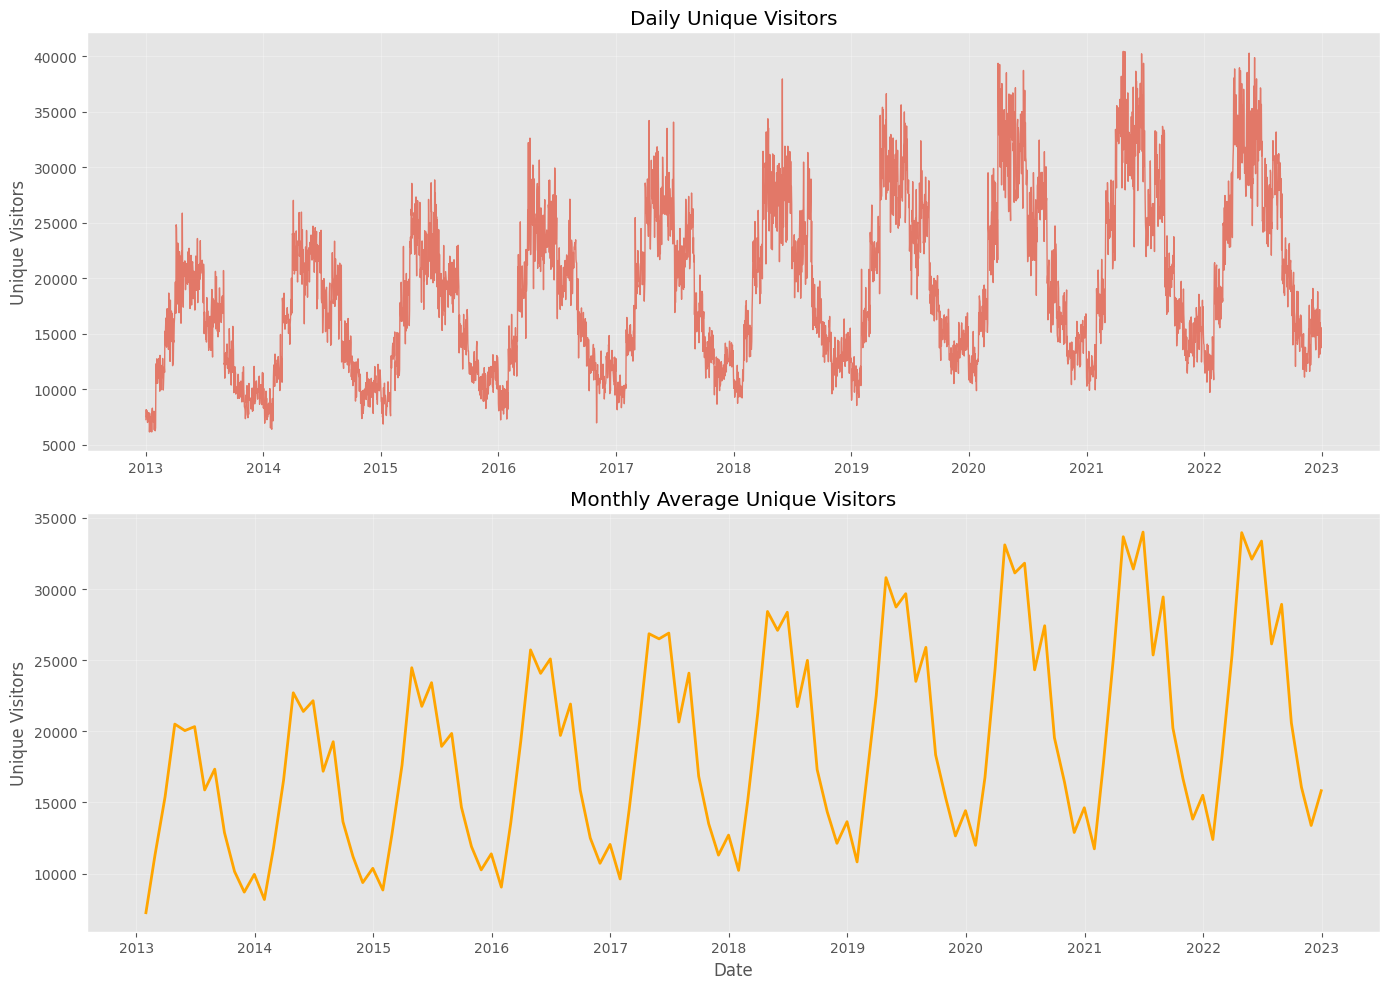

In [13]:
# Resample to monthly average
monthly_avg = web_traffic.set_index('date')['unique_visitors'].resample('ME').mean()
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily data
axes[0].plot(web_traffic['date'], web_traffic['unique_visitors'], linewidth=1, alpha=0.7, label='Daily')
axes[0].set_title('Daily Unique Visitors')
axes[0].set_ylabel('Unique Visitors')
axes[0].grid(True, alpha=0.3)

# Monthly average
axes[1].plot(monthly_avg.index, monthly_avg.values, linewidth=2, color='orange', label='Monthly Avg')
axes[1].set_title('Monthly Average Unique Visitors')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Unique Visitors')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
customers.head(10)

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search
5,6,15202,Phu Ly,2022-04-14,Female,25-34,organic_search
6,8,15202,Phu Ly,2015-09-11,Male,45-54,social_media
7,9,15202,Phu Ly,2020-02-14,Male,35-44,email_campaign
8,10,15202,Phu Ly,2014-03-03,Male,25-34,organic_search
9,11,15203,Viet Tri,2017-11-07,Male,35-44,organic_search


In [23]:
customers['acquisition_channel'].value_counts()

acquisition_channel
organic_search    36450
social_media      24448
paid_search       24285
email_campaign    14674
referral          12270
direct             9803
Name: count, dtype: int64

In [24]:
customers['age_group'].value_counts()

age_group
25-34    36342
35-44    31920
45-54    23172
18-24    17039
55+      13457
Name: count, dtype: int64

In [56]:
sales.head(10)

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
5,2012-07-09,3548386.46,2787841.68
6,2012-07-10,5234938.62,4044438.84
7,2012-07-11,5582884.78,4338313.07
8,2012-07-12,5734632.02,4458811.27
9,2012-07-13,5309511.71,4143402.78


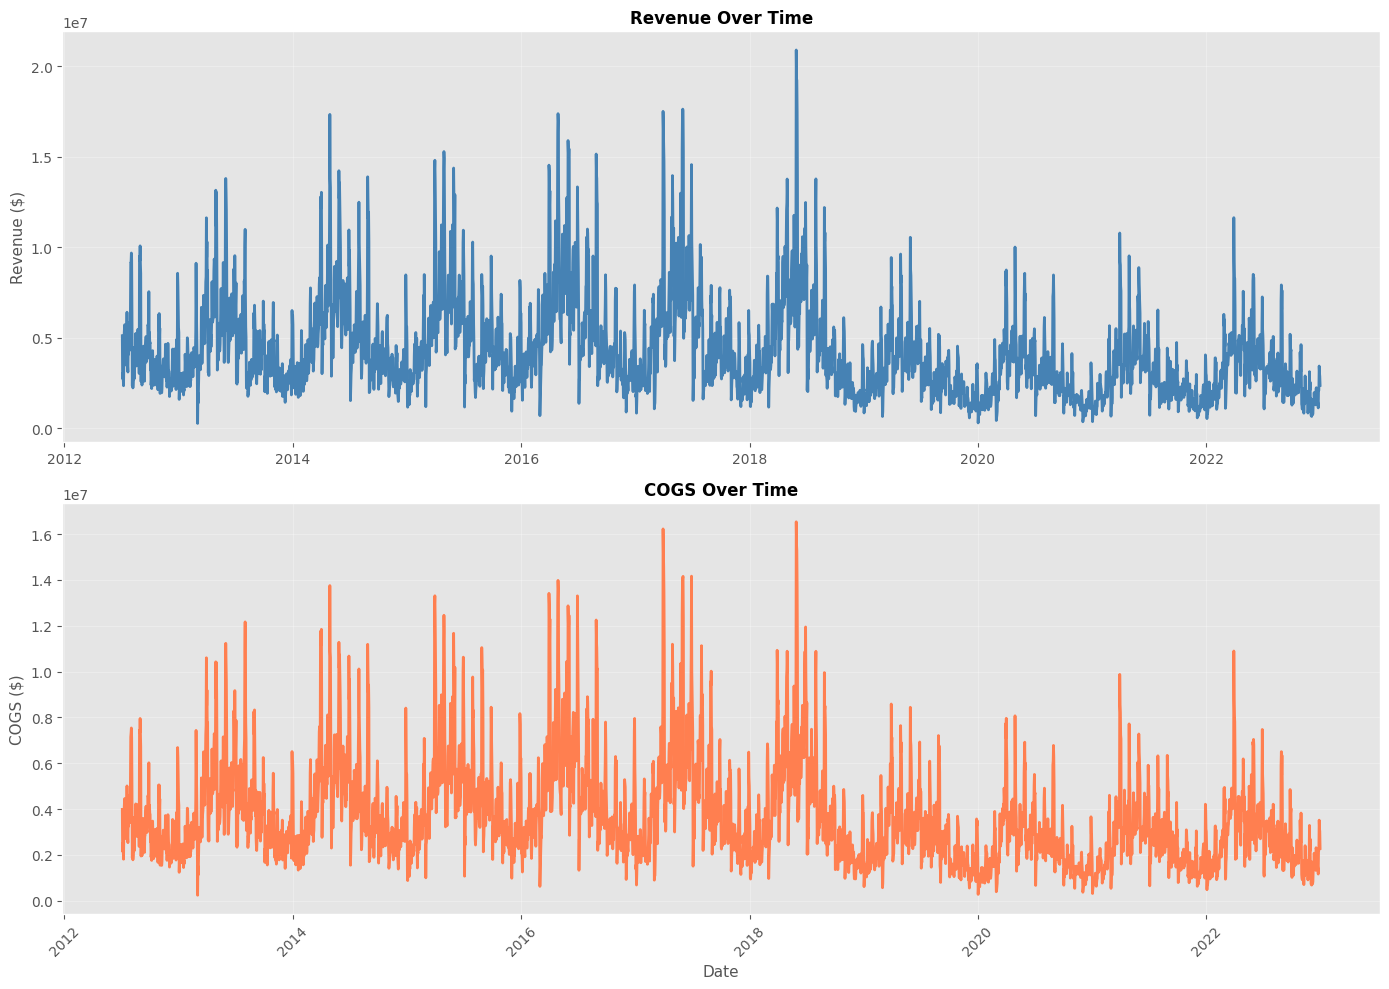

In [59]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Revenue
axes[0].plot(sales['Date'], sales['Revenue'], linewidth=2, color='steelblue')
axes[0].set_title('Revenue Over Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue ($)', fontsize=11)
axes[0].grid(True, alpha=0.3)

# COGS
axes[1].plot(sales['Date'], sales['COGS'], linewidth=2, color='coral')
axes[1].set_title('COGS Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('COGS ($)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

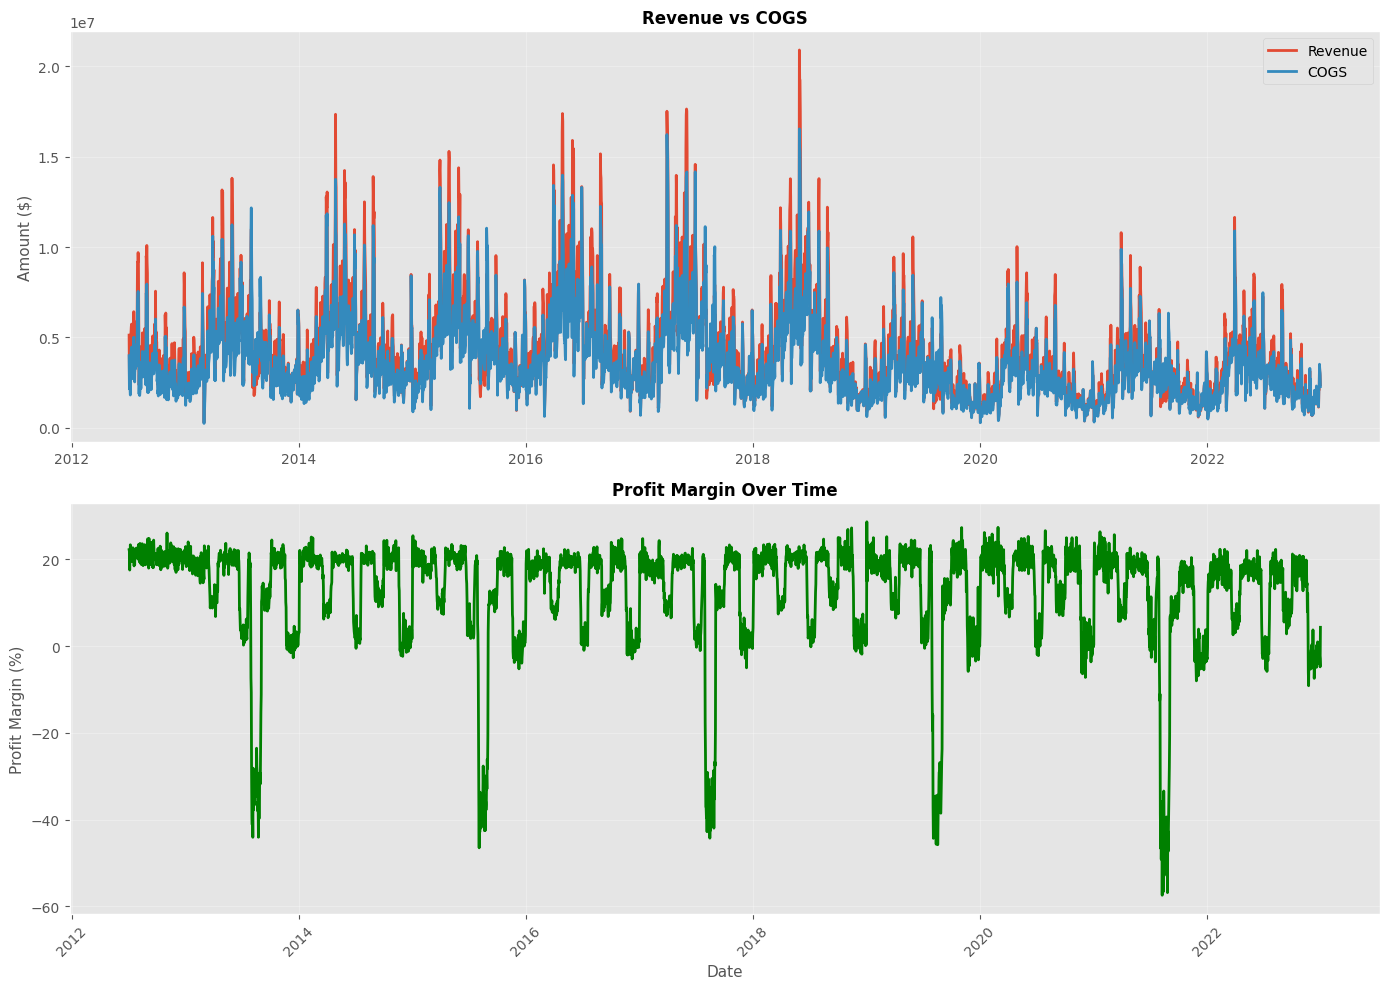

In [60]:
# Calculate profit
sales['Profit'] = sales['Revenue'] - sales['COGS']
sales['Profit_Margin'] = (sales['Profit'] / sales['Revenue'] * 100)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Revenue and COGS
axes[0].plot(sales['Date'], sales['Revenue'], linewidth=2, label='Revenue')
axes[0].plot(sales['Date'], sales['COGS'], linewidth=2, label='COGS')
axes[0].set_title('Revenue vs COGS', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amount ($)', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Profit Margin
axes[1].plot(sales['Date'], sales['Profit_Margin'], linewidth=2, color='green')
axes[1].set_title('Profit Margin Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Profit Margin (%)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Ensure Date is datetime
sales['Date'] = pd.to_datetime(sales['Date'])

# Extract year
sales['Year'] = sales['Date'].dt.year

# Get unique years and sort
years = sorted(sales['Year'].unique())

# Create subplots for each year
num_years = len(years)
fig, axes = plt.subplots(num_years, 1, figsize=(14, 4 * num_years))

# Handle case where there's only one year
if num_years == 1:
    axes = [axes]

# Plot each year
for idx, year in enumerate(years):
    year_data = sales[sales['Year'] == year]
    axes[idx].plot(year_data['Date'], year_data['Profit_Margin'], linewidth=2, color='green', marker='o', markersize=4)
    axes[idx].set_title(f'Profit Margin Over Time - {year}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Profit Margin (%)', fontsize=11)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

# Set x-label only on the last subplot
axes[-1].set_xlabel('Date', fontsize=11)

plt.tight_layout()
plt.show()
